/hpc/home/of21/.local/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
<ipython-input-1-f6c8d28c1998>:148: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_other["Group_Other"] = df_other.apply(label_group_other, axis=1)


Combined Color Map:
Stromal_Muscle: #D35C5C
Stromal_Adipose: #D35C5C
Stromal_Artery: #D35C5C
Stromal_Skin: #D35C5C
Endothelial_Muscle: #56A0D3
Endothelial_Adipose: #56A0D3
Epithelial_Non-Glandular_Organ: #5DBD71
Epithelial_Tongue: #5DBD71
Epithelial_Intestine: #5DBD71
Stromal_Other: #D35C5C
Endothelial_Other: #56A0D3
Epithelial_Other: #5DBD71
Other: gray


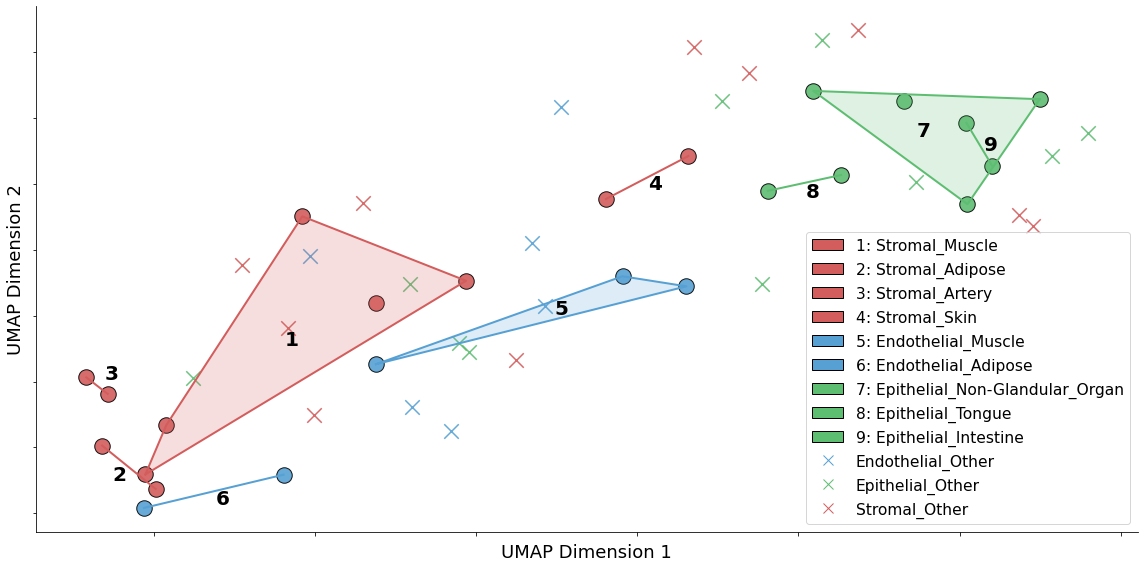

In [1]:
import pandas as pd
import numpy as np
import umap.umap_ as umap
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.spatial import ConvexHull
import random

# 1) Define file paths
endothelial_path = "/hpc/group/xielab/yx275/Endothelial/all_signaling_pathways_results.csv"
epithelial_path  = "/hpc/group/xielab/yx275/Epithelial/all_signaling_pathways_results.csv"
stromal_path     = "/hpc/group/xielab/yx275/Stromal/all_signaling_pathways_results.csv"

# 2) Read CSV files
df_endothelial = pd.read_csv(endothelial_path)
df_epithelial  = pd.read_csv(epithelial_path)
df_stromal     = pd.read_csv(stromal_path)

# 3) Define a helper to reshape z-scores into 13D vectors
def extract_effect_size(df, vector_size=13):
    z_scores = df['z_score'].values
    transformed = np.log1p(z_scores)  # log(1 + z)
    if len(transformed) % vector_size != 0:
        raise ValueError(f"Rows not a multiple of {vector_size}.")
    return transformed.reshape(-1, vector_size)

vectors_endothelial = extract_effect_size(df_endothelial)
vectors_epithelial  = extract_effect_size(df_epithelial)
vectors_stromal     = extract_effect_size(df_stromal)

# 4) Combine all vectors and keep track of group labels
all_vectors = np.concatenate([vectors_endothelial, vectors_epithelial, vectors_stromal])
n_end = len(vectors_endothelial)
n_epi = len(vectors_epithelial)
n_str = len(vectors_stromal)

group_labels = (
    ["Endothelial"]*n_end + 
    ["Epithelial"]*n_epi + 
    ["Stromal"]*n_str
)

# 5) Extract tissue types for each 13D block
df_all = pd.concat([df_endothelial, df_epithelial, df_stromal], ignore_index=True)
tissues = df_all['tissue'].values
vector_size = 13
tissue_labels = [tissues[i] for i in range(0, len(tissues), vector_size)]

# 6) Scale and do a 2D UMAP
scaler = StandardScaler()
scaled_all_vectors = scaler.fit_transform(all_vectors)

umap_2d = umap.UMAP(n_components=2, random_state=42)
embedding_2d = umap_2d.fit_transform(scaled_all_vectors)

# 7) Build a DataFrame with the UMAP coords, group, tissue
df_clustered = pd.DataFrame({
    "UMAP_Dim1": embedding_2d[:, 0],
    "UMAP_Dim2": embedding_2d[:, 1],
    "Group": group_labels,
    "Tissue": tissue_labels
})

# 8) Define subcategory functions
def stromal_subcategory(tissue_name):
    t = tissue_name.lower()
    if any(k in t for k in ["muscle", "myometrium"]):
        return "Stromal_Muscle"
    elif any(k in t for k in ["adipose", "Adipose"]):
        return "Stromal_Adipose"
    elif any(k in t for k in ["skin"]):
        return "Stromal_Skin"
    elif any(k in t for k in ["artery", "aorta"]):
        return "Stromal_Artery"
    else:
        return "Stromal_Other"

def epithelial_subcategory(tissue_name):
    t = tissue_name.lower()
    if any(k in t for k in ["kidney", "liver", "bladder", "lung"]):
        return "Epithelial_Non-Glandular_Organ"
    elif any(k in t for k in ["large_intestine", "small_intestine"]):
        return "Epithelial_Intestine"
    elif any(k in t for k in ["tongue"]):
        return "Epithelial_Tongue"
    else:
        return "Epithelial_Other"

def endothelial_subcategory(tissue_name):
    t = tissue_name.lower()
    if any(k in t for k in ["adipose", "Adipose"]):
        return "Endothelial_Adipose"
    elif any(k in t for k in ["muscle"]):
        return "Endothelial_Muscle"
    else:
        return "Endothelial_Other"

def assign_subcategory(row):
    g = row["Group"]
    t = row["Tissue"]
    if g == "Stromal":
        return stromal_subcategory(t)
    elif g == "Epithelial":
        return epithelial_subcategory(t)
    elif g == "Endothelial":
        return endothelial_subcategory(t)
    else:
        return "Other"

df_clustered["SubCategory"] = df_clustered.apply(assign_subcategory, axis=1)

# --------------------
# 9) SELECT SUBCATS OF INTEREST
# --------------------
target_subcats = [
    # Stromal
    "Stromal_Muscle", 
    "Stromal_Adipose",
    "Stromal_Artery",
    "Stromal_Skin",
    # Endothelial
    "Endothelial_Muscle",
    "Endothelial_Adipose",
    # Epithelial
    "Epithelial_Non-Glandular_Organ",
    "Epithelial_Tongue",
    "Epithelial_Intestine",
]

df_filtered = df_clustered[df_clustered["SubCategory"].isin(target_subcats)]
df_other = df_clustered[~df_clustered["SubCategory"].isin(target_subcats)]

# We want to further split df_other into 3 categories:
# "Stromal_Other", "Epithelial_Other", "Endothelial_Other"
def label_group_other(row):
    if row["Group"] == "Stromal":
        return "Stromal_Other"
    elif row["Group"] == "Endothelial":
        return "Endothelial_Other"
    elif row["Group"] == "Epithelial":
        return "Epithelial_Other"
    else:
        return "Other"

df_other["Group_Other"] = df_other.apply(label_group_other, axis=1)

# --------------------
# 10) DEFINE COLORS AND NUMBER MAPPING
# --------------------
# Define the updated Subcategory Color Map with Oranges, Blues, and Greens
subcat_color_map = {
    # Stromal Subcategories
    "Stromal_Muscle":        "#D35C5C",  
    "Stromal_Adipose":           "#D35C5C",  
    "Stromal_Artery":        "#D35C5C",
    "Stromal_Skin":          "#D35C5C",

    # Endothelial Subcategories
    "Endothelial_Muscle":    "#56A0D3", 
    "Endothelial_Adipose":       "#56A0D3",

    # Epithelial Subcategories
    "Epithelial_Non-Glandular_Organ": "#5DBD71",  
    "Epithelial_Tongue":     "#5DBD71",  
    "Epithelial_Intestine":  "#5DBD71",
}

# Define the updated Other Category Color Map with lighter shades
other_color_map = {
    "Stromal_Other":     "#D35C5C",  # Warm red
    "Endothelial_Other": "#56A0D3",  # Carolina Blue
    "Epithelial_Other":  "#5DBD71",  # Warm Green
    "Other":             "gray"      
}

# Combine both color maps into one
combined_color_map = {**subcat_color_map, **other_color_map}

# Assign unique numbers to target subcategories
number_mapping = {subcat: idx+1 for idx, subcat in enumerate(target_subcats)}

# Display the combined color map for verification
print("Combined Color Map:")
for category, color in combined_color_map.items():
    print(f"{category}: {color}")

# --------------------
# 11) PLOT WITH NUMBERS
# --------------------
fig, ax = plt.subplots(figsize=(16, 8))  # Increased size for better visibility

# Dictionary to store centroids for labeling
group_centroids = {}

# 11a) FIRST: plot the target subcategories with lines/hulls and add numbers
for subcat in target_subcats:
    mask = (df_filtered["SubCategory"] == subcat)
    points = df_filtered.loc[mask, ["UMAP_Dim1", "UMAP_Dim2"]].values
    
    color = subcat_color_map.get(subcat, "gray")
    
    # Scatter points
    scatter = ax.scatter(points[:, 0], points[:, 1],
                         c=color, label=subcat, alpha=0.9,
                         edgecolor='k', s=240)
    
    # If exactly 2 points, connect with a line
    if len(points) == 2:
        ax.plot(points[:, 0], points[:, 1], c=color, lw=2)
    
    # If >= 3 points, draw a convex hull
    elif len(points) >= 3:
        hull = ConvexHull(points)
        hull_vertices = hull.vertices
        # close the polygon
        hull_vertices = np.append(hull_vertices, hull_vertices[0])
        
        ax.plot(points[hull_vertices, 0],
                points[hull_vertices, 1],
                c=color, lw=2)
        
        ax.fill(points[hull_vertices, 0],
                points[hull_vertices, 1],
                facecolor=color, alpha=0.2)
    
    # Calculate centroid for placing the number
    centroid = points.mean(axis=0)
    group_centroids[subcat] = centroid
    
    # --------------------
    # **Adjust the centroid for 'Stromal_Artery' to prevent overlap**
    # --------------------
    if subcat == "Stromal_Artery":
        # Define the offset values
        offset_x = 0.09  # Shift to the right
        offset_y = 0.09  # Shift upwards
        centroid = centroid + np.array([offset_x, offset_y])
    
    if subcat == "Stromal_Adipose":
        # Define the offset values
        offset_x = -0.06  # Shift to the left
        offset_y = -0.06  # Shift down
        centroid = centroid + np.array([offset_x, offset_y])
    if subcat == "Stromal_Skin":
        # Define the offset values
        offset_x = 0.05 
        offset_y = -0.05
        centroid = centroid + np.array([offset_x, offset_y])
    
    if subcat == "Epithelial_Tongue":
        # Define the offset values
        offset_x = 0.05
        offset_y = -0.07
        centroid = centroid + np.array([offset_x, offset_y])
    
    if subcat == "Epithelial_Intestine":
        # Define the offset values
        offset_x = 0.07
        offset_y = 0
        centroid = centroid + np.array([offset_x, offset_y])
        
    if subcat == "Epithelial_Non-Glandular_Organ":
        # Define the offset values
        offset_x = -0.05
        offset_y = -0.05
        centroid = centroid + np.array([offset_x, offset_y])
    
    if subcat == "Endothelial_Adipose":
        # Define the offset values
        offset_x = 0.055 
        offset_y = -0.055
        centroid = centroid + np.array([offset_x, offset_y])
    
    # Add the number annotation
    ax.text(centroid[0], centroid[1], str(number_mapping[subcat]), 
            fontsize=20, weight='bold',
            ha='center', va='center', color='black')
           # bbox=dict(facecolor='white', edgecolor='none', alpha=0.2, pad=1))

# 11b) THEN: plot all OTHER points (no hulls/lines, marker='x')
unique_other_groups = df_other["Group_Other"].unique()
for grp_oth in unique_other_groups:
    mask = (df_other["Group_Other"] == grp_oth)
    points = df_other.loc[mask, ["UMAP_Dim1", "UMAP_Dim2"]].values
    
    color = other_color_map.get(grp_oth, "gray")
    # marker='x' to distinguish
    ax.scatter(points[:, 0], points[:, 1],
               c=color, label=grp_oth, alpha=0.9,
               edgecolor='k', s=210, marker='x')

# 11c) Titles, labels
ax.set_xlabel("UMAP Dimension 1", fontsize=18)
ax.set_ylabel("UMAP Dimension 2", fontsize=18)
#ax.set_title("UMAP Projection of Signaling Pathways", fontsize=16)

# Build legend with numbers
legend_elements = []

# Add legend entries for target subcategories with numbers
for subcat in target_subcats:
    num = number_mapping[subcat]
    color = subcat_color_map.get(subcat, "gray")
    legend_elements.append(Patch(facecolor=color, edgecolor='k',
                                 label=f"{num}: {subcat}"))

# Add legend entries for 'Other' categories
for grp_oth in unique_other_groups:
    color = other_color_map.get(grp_oth, "gray")
    legend_elements.append(Line2D([0], [0], marker='x', color='w',
                                  label=grp_oth, markerfacecolor='none',
                                  markeredgecolor=color, markersize=10, linewidth=0))

# Remove the top and right spines
sns.despine(top=True, right=True)

# Remove numerical tick labels from both axes
ax.set_yticklabels([])
ax.set_xticklabels([])

# Remove the legend title by setting title=None
ax.legend(handles=legend_elements, title=None, loc='best', fontsize = 15.5)

# Adjust layout to prevent clipping of labels
plt.tight_layout()

plt.savefig("/hpc/group/xielab/of21/human_atlas_umap_final.jpeg", dpi=600)

# Display the plot
plt.show()


# Package Requirements

In [2]:
import pandas as pd
import numpy as np
import umap.umap_ as umap
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.spatial import ConvexHull
import random

# Print versions of the packages being used
print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)
print("seaborn version:", sns.__version__)
import sklearn
print("scikit-learn version:", sklearn.__version__)
print("matplotlib version:", matplotlib.__version__)
import scipy
print("scipy version:", scipy.__version__)


pandas version: 1.2.4
numpy version: 1.24.4
seaborn version: 0.11.1
scikit-learn version: 0.24.1
matplotlib version: 3.3.4
scipy version: 1.10.1
